# Baseline: Mid-Price Move + Direction Models

- Decompose problem into two models:
  - Model 1: predict if price moves (**P(move)**)
  - Model 2: predict direction given a move (**P(up | move)**)

- Model 1 captures **market activity/state**
  - driven by volatility, trade activity, spread, liquidity
  - typically stronger and more stable

- Model 2 captures **directional pressure**
  - driven by imbalance, microprice, trade flow
  - weaker and more regime-dependent
  - contains actual alpha

- Final signal:
  P(up) = P(move) × P(up | move)

- Separating the problems avoids mixing activity and direction  


# Feature Selection Approach

- Use Model 1 (P(move)) to identify which **types of features drive market activity**

- Apply L1 regularisation to select a sparse set of important features  
  - note: L1 may arbitrarily pick one feature from correlated groups  

- Expand selected features into **feature groups** (e.g. imbalance, depth, trade activity)  
  - preserves full microstructure signal within each group  

- Refit model using L2 on expanded feature set  
  - obtain stable and interpretable coefficients  
  - properly distribute weight across correlated features  

- Result: robust understanding of which **feature classes matter**, not just individual variables

In [1]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [2]:
target = "mid_price_moves"

In [3]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet")

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

In [4]:
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)

final_dataset = final_dataset.dropna().reset_index(drop=True)

final_dataset[target].value_counts()

mid_price_moves
0    25213
1    18786
Name: count, dtype: int64

# Full feature list

In [5]:
lob_features = [
    #"lob_bids_price_1",
    #"lob_bids_price_2",
    #"lob_bids_price_3",
    #"lob_bids_price_4",
    #"lob_bids_price_5",
    #"lob_bids_price_6",
    #"lob_bids_price_7",
    #"lob_bids_price_8",
    #"lob_bids_price_9",
    #"lob_bids_price_10",
    #"lob_bids_volume_1",
    #"lob_bids_volume_2",
    #"lob_bids_volume_3",
    #"lob_bids_volume_4",
    #"lob_bids_volume_5",
    #"lob_bids_volume_6",
    #"lob_bids_volume_7",
    #"lob_bids_volume_8",
    #"lob_bids_volume_9",
    #"lob_bids_volume_10",
    #"lob_asks_price_1",
    #"lob_asks_price_2",
    #"lob_asks_price_3",
    #"lob_asks_price_4",
    #"lob_asks_price_5",
    #"lob_asks_price_6",
    #"lob_asks_price_7",
    #"lob_asks_price_8",
    #"lob_asks_price_9",
    #"lob_asks_price_10",
    #"lob_asks_volume_1",
    #"lob_asks_volume_2",
    #"lob_asks_volume_3",
    #"lob_asks_volume_4",
    #"lob_asks_volume_5",
    #"lob_asks_volume_6",
    #"lob_asks_volume_7",
    #"lob_asks_volume_8",
    #"lob_asks_volume_9",
    #"lob_asks_volume_10",
    "lob_depth_ratio_2",
    "lob_depth_ratio_3",
    "lob_depth_ratio_4",
    "lob_depth_ratio_5",
    "lob_depth_ratio_6",
    "lob_depth_ratio_7",
    "lob_depth_ratio_8",
    "lob_depth_ratio_9",
    "lob_depth_ratio_10",
]

spread_features = [
    #"rel_spread",
    # "spread"
    ]
imbalance_features = [
    "imbalance_1",
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_1",
    "imbalance_depth_2",
    "imbalance_depth_3",
    "imbalance_depth_4",
    "imbalance_depth_5",
    "imbalance_depth_6",
    "imbalance_depth_7",
    "imbalance_depth_8",
    "imbalance_depth_9",
    "imbalance_depth_10",
]
liquidity_features = [
    #"liquidity",
    #"total_bid_volume_10",
    #"total_ask_volume_10",
    #"total_book_volume",
    #"max_bid_ask_vol_ratio",
]
microprice_features = [
    "microprice",
    "microprice_change",
    #"mid_minus_micro",
    "microprice_weighted_10",
]
return_features = [
    #"return_1",
    #"return_5",
    "log_return_1",
    "log_return_2",
    "log_return_3",
    "log_return_5",
    "log_return_20",
    "mid_price_change_1",
    "mid_price_change_5",
    "mid_price_change_20",
]
momentum_features = [
    "momentum_5_log_return_1",
    "momentum_20_log_return_1",
]
volatility_features = [
    #"vol_5",
    #"vol_20",
    #"realized_vol_5",
    #"realized_vol_20",
]
trade_activity_features = [
    #"trade_count",
    #    "buy_count",
    #        "sell_count",
]
trade_volume_features = [
 #   "total_trade_volume",
 #   "buy_volume",
 #   "sell_volume",
 #   "avg_trade_size",
 #   "max_trade_size",
 #   "min_trade_size",
 #   "std_trade_size",
 #   "max_over_average",
]
trade_flow_features = [
    "trade_volume_imbalance",
]
trade_dynamics_features = [
    "trade_volume_change",
    "trade_count_change",
]
lagged_trade_features = [
    "lag_trade_volume_imbalance_1",
    "lag_trade_volume_imbalance_2",
    "lag_trade_volume_imbalance_3",
    "lag_trade_volume_imbalance_5",
]
feature_groups = {
    "lob_features": lob_features,
    "spread": spread_features,
    "imbalance": imbalance_features,
    "liquidity": liquidity_features,
    "microprice": microprice_features,
    "returns": return_features,
    "momentum": momentum_features,
    "volatility": volatility_features,
    "trade_activity": trade_activity_features,
    "trade_volume": trade_volume_features,
    "trade_flow": trade_flow_features,
    "trade_dynamics": trade_dynamics_features,
    "lagged_trade": lagged_trade_features,
}
all_features = (
    lob_features
    + spread_features
    + imbalance_features
    + liquidity_features
    + microprice_features
    + return_features
    + momentum_features
    + volatility_features
    + trade_activity_features
    + trade_volume_features
    + trade_flow_features
    + trade_dynamics_features
    + lagged_trade_features
)

In [6]:
transformed = [


    "lob_bids_volume_1_log1p",
    "lob_bids_volume_2_log1p",
    "lob_bids_volume_3_log1p",
    "lob_bids_volume_4_log1p",
    "lob_bids_volume_5_log1p",
    "lob_bids_volume_6_log1p",
    "lob_bids_volume_7_log1p",
    "lob_bids_volume_8_log1p",
    "lob_bids_volume_9_log1p",
    "lob_bids_volume_10_log1p",

    "rel_spread_log1p",
    "spread_log1p",

    "liquidity_log1p",
    "total_bid_volume_10_log1p",
    "total_ask_volume_10_log1p",
    "total_book_volume_log1p",
    "max_bid_ask_vol_ratio_log1p",

    "mid_minus_micro_log1p",

    "vol_5_log1p",
    "vol_20_log1p",
    "realized_vol_5_log1p",
    "realized_vol_20_log1p",

    "trade_count_log1p",
    "buy_count_log1p",
    "sell_count_log1p",


    "total_trade_volume_log1p",
    "buy_volume_log1p",
    "sell_volume_log1p",
    "avg_trade_size_log1p",
    "max_trade_size_log1p",
    "min_trade_size_log1p",
    "std_trade_size_log1p",
    "max_over_average_log1p",
]

In [7]:
features = all_features + transformed
print(features)

['lob_depth_ratio_2', 'lob_depth_ratio_3', 'lob_depth_ratio_4', 'lob_depth_ratio_5', 'lob_depth_ratio_6', 'lob_depth_ratio_7', 'lob_depth_ratio_8', 'lob_depth_ratio_9', 'lob_depth_ratio_10', 'imbalance_1', 'imbalance_5', 'imbalance_10', 'imbalance_depth_1', 'imbalance_depth_2', 'imbalance_depth_3', 'imbalance_depth_4', 'imbalance_depth_5', 'imbalance_depth_6', 'imbalance_depth_7', 'imbalance_depth_8', 'imbalance_depth_9', 'imbalance_depth_10', 'microprice', 'microprice_change', 'microprice_weighted_10', 'log_return_1', 'log_return_2', 'log_return_3', 'log_return_5', 'log_return_20', 'mid_price_change_1', 'mid_price_change_5', 'mid_price_change_20', 'momentum_5_log_return_1', 'momentum_20_log_return_1', 'trade_volume_imbalance', 'trade_volume_change', 'trade_count_change', 'lag_trade_volume_imbalance_1', 'lag_trade_volume_imbalance_2', 'lag_trade_volume_imbalance_3', 'lag_trade_volume_imbalance_5', 'lob_bids_volume_1_log1p', 'lob_bids_volume_2_log1p', 'lob_bids_volume_3_log1p', 'lob_bid

# Splitting data

In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [9]:
tscv = TimeSeriesSplit(n_splits=10, gap=50)

# l1 training for feature selection

Data

In [10]:
X = final_dataset[features]
y = final_dataset[target]

model

In [11]:
model = LogisticRegression(
    l1_ratio=1,
    solver="saga",
    C=1.0,
    max_iter=5000,
)

In [12]:
#fold_aucs = []
#coefs = []
#all_oof_preds = []
#
#for train_idx, test_idx in tscv.split(final_dataset):
#    oof_preds = np.zeros(len(final_dataset))
#
#    X_train = X.iloc[train_idx].copy()
#    X_test = X.iloc[test_idx].copy()
#    y_train = y.iloc[train_idx]
#    y_test = y.iloc[test_idx]
#
#    # clip
#    lower = X_train.quantile(0.001)
#    upper = X_train.quantile(0.999)
#
#    X_train = X_train.clip(lower, upper, axis=1)
#    X_test = X_test.clip(lower, upper, axis=1)
#    # standardize
#
#    mean = X_train.mean()
#    std = X_train.std()
#    std[std < 1e-12] = 1.0
#
#    X_train = (X_train - mean) / std
#    X_test = (X_test - mean) / std
#    # --- MODEL ---
#    model.fit(X_train, y_train)
#
#    preds = model.predict_proba(X_test)[:, 1]
#    oof_preds[test_idx] = preds
#    auc = roc_auc_score(y_test, preds)
#
#    all_oof_preds.append(oof_preds)
#    fold_aucs.append(auc)
#    coefs.append(model.coef_[0])#

In [13]:
from joblib import Parallel, delayed
import numpy as np
from sklearn.metrics import roc_auc_score

def run_fold(train_idx, test_idx, X, y, model):

    oof_preds = np.zeros(len(X))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # --- CLIP ---
    lower = X_train.quantile(0.001)
    upper = X_train.quantile(0.999)

    X_train = X_train.clip(lower, upper, axis=1)
    X_test = X_test.clip(lower, upper, axis=1)

    # --- STANDARDISE ---
    mean = X_train.mean()
    std = X_train.std()
    std[std < 1e-12] = 1.0

    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    # --- MODEL ---
    model_ = model.__class__(**model.get_params())  # fresh copy
    model_.fit(X_train, y_train)

    preds = model_.predict_proba(X_test)[:, 1]
    oof_preds[test_idx] = preds

    auc = roc_auc_score(y_test, preds)
    coefs = model_.coef_[0]

    return oof_preds, auc, coefs

In [14]:
results = Parallel(n_jobs=4)(
    delayed(run_fold)(train_idx, test_idx, X, y, model)
    for train_idx, test_idx in tscv.split(X)
)

In [15]:
all_oof_preds = []
fold_aucs = []
coefs = []

for oof, auc, coef in results:
    all_oof_preds.append(oof)
    fold_aucs.append(auc)
    coefs.append(coef)

[0.7746225400066312, 0.834603259946082, 0.6802889080717244, 0.7003751591076572, 0.6960870441809702, 0.7218658356854344, 0.6860133496933041, 0.7254023002458397, 0.6897544812043599, 0.796363873622662]


C:\Users\jayod\AppData\Local\Temp\ipykernel_15540\2869559075.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'AUC per Fold')

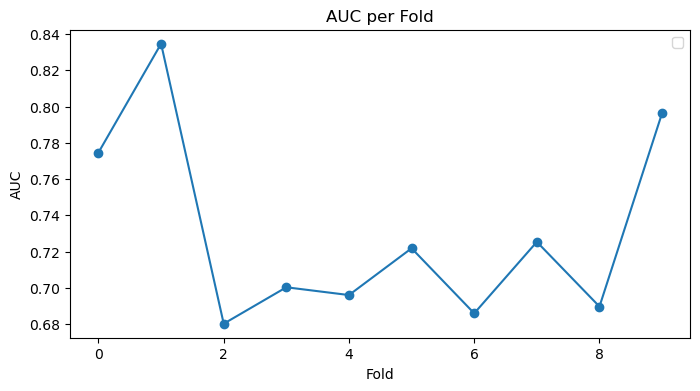

In [16]:
print(fold_aucs)
plt.figure(figsize=(8,4))

plt.plot(fold_aucs, marker="o")

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.legend()
plt.title("AUC per Fold")

In [17]:
final_preds = np.sum(all_oof_preds, axis=0)
y_true = y.values

Text(0.5, 1.0, 'Rolling Calibration (window=500)')

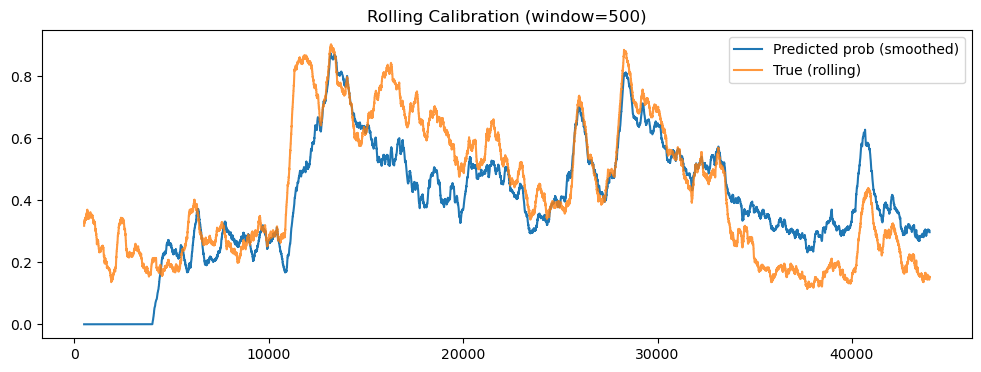

In [18]:
import matplotlib.pyplot as plt

window = 500

pred_smooth = pd.Series(final_preds).rolling(window).mean()
target_smooth = pd.Series(y_true).rolling(window).mean()

plt.figure(figsize=(12,4))
plt.plot(pred_smooth, label="Predicted prob (smoothed)")
plt.plot(target_smooth, label="True (rolling)", alpha=0.8)
plt.legend()
plt.title(f"Rolling Calibration (window={window})")

Text(0.5, 1.0, 'Prediction distribution')

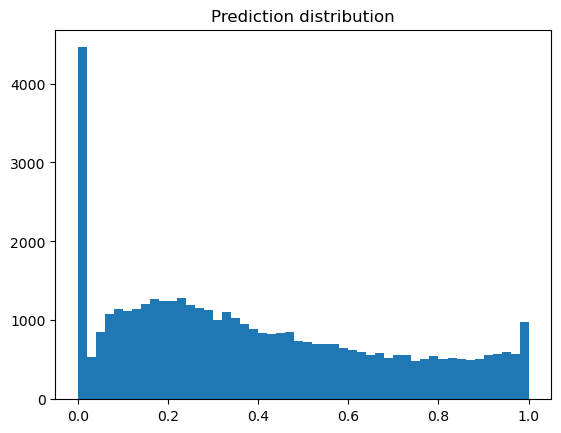

In [19]:
plt.hist(final_preds, bins=50)
plt.title("Prediction distribution")

In [20]:
import pandas as pd

avg_coefs = pd.Series(np.mean(coefs, axis=0), index=features)
avg_coefs = avg_coefs.sort_values(key=abs, ascending=False)
pd.set_option("display.max_rows", None)
print(avg_coefs)

realized_vol_20_log1p           1.402614
trade_count_log1p               1.143365
total_ask_volume_10_log1p      -0.803893
max_trade_size_log1p            0.767264
vol_20_log1p                   -0.740781
total_book_volume_log1p         0.565456
max_over_average_log1p         -0.558968
std_trade_size_log1p           -0.536708
avg_trade_size_log1p           -0.509493
trade_count_change              0.432632
total_bid_volume_10_log1p      -0.401705
max_bid_ask_vol_ratio_log1p     0.369198
realized_vol_5_log1p            0.320503
lob_bids_volume_1_log1p        -0.314122
spread_log1p                    0.237961
buy_count_log1p                -0.218017
imbalance_10                   -0.187844
total_trade_volume_log1p        0.170689
lob_depth_ratio_2              -0.151714
imbalance_depth_5              -0.149434
lob_depth_ratio_5               0.140341
rel_spread_log1p                0.137641
imbalance_depth_2               0.131448
vol_5_log1p                    -0.114897
lob_depth_ratio_

In [21]:
sorted_tables = []

for i in range(len(coefs)):
    s = pd.Series(coefs[i], index=features)
    s = s.sort_values(key=abs, ascending=False)

    df_fold = pd.DataFrame({
        f"Fold_{i}_feature": s.index,
        f"Fold_{i}_coef": s.values
    })

    sorted_tables.append(df_fold.reset_index(drop=True))

In [22]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


coef_table = pd.concat(sorted_tables, axis=1)

print(coef_table)

                  Fold_0_feature  Fold_0_coef                Fold_1_feature  Fold_1_coef                Fold_2_feature  Fold_2_coef                Fold_3_feature  Fold_3_coef                Fold_4_feature  Fold_4_coef                Fold_5_feature  Fold_5_coef                Fold_6_feature  Fold_6_coef                Fold_7_feature  Fold_7_coef                Fold_8_feature  Fold_8_coef                Fold_9_feature  Fold_9_coef
0              trade_count_log1p     1.990428             trade_count_log1p     1.747680         realized_vol_20_log1p     1.627082         realized_vol_20_log1p     1.594238         realized_vol_20_log1p     1.579322         realized_vol_20_log1p     1.676227         realized_vol_20_log1p     1.654155         realized_vol_20_log1p     1.502421         realized_vol_20_log1p     1.470488         realized_vol_20_log1p     1.369082
1           max_trade_size_log1p     1.644774         realized_vol_20_log1p     1.214691             trade_count_log1p     1.598442   

In [23]:
from prettytable import PrettyTable

for i in range(len(sorted_tables)):
    df = sorted_tables[i].round(4)

    table = PrettyTable()
    table.field_names = ["feature", "coef"]

    for row in df.values:
        table.add_row(row)

    with open(f"C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\saved_info\\l1_fold\\fold_{i}.txt", "w") as f:
        f.write(str(table))

In [24]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["feature", "avg_coef"]

for feature, coef in avg_coefs.round(4).items():
    table.add_row([feature, coef])

with open("C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\saved_info\\l1_fold\\avg.txt", "w") as f:
    f.write(str(table))